# Homework 3 - Adversarial Attacks and Contrastive Learning

### Submission Guidelines

- This notebook contains all the questions. You should follow the instructions below.
- Solutions for the practical parts should be written in this notebook/py (see submission files) and for the dry "theoretical" parts in a pdf report.

You should submit the following files:
- Code files - You can choose 1 of the following options:
  - IPYNB notebook including the solutions to all 4 parts. The `.ipynb` file should not include any answers to dry questions because they should all be in the PDF report. Markdown cells in the notebook will not be checked.
  - PY files: 2 `.py` files, one for questions 1-3 and one for question 4. Submission format for `.py` files -  `HW3_Partn_ID1_ID2.py` where `n=1` is for parts 1-3 and `n=2` is for part 4.

- PDF file - report:
  - Answers for all the dry parts - analysis, visualization, dry questions, embeddings. You must create a PDF report, even if you chose to implement your code using a Jupyter Notebook. The PDF should not be a PDF version of the notebook and doesn't need to include any code.

Good Luck!

Libraries that can be used in this assignment:

- PyTorch (torch, torchvision, torch.optim, torch.nn, ...) -- Any other deep learning libraries such as keras are prohibited
- NumPy
- Any libraries used for visualization
- PIL (for image processing)

For any libraries other than those listed above, you may ask in the forum.

## Theory - Neural Network Expressivity (20pt)

Solve the following exercises rigorously. Note that your proof does not need to be typed (can be handwritten), and answers should be in the PDF report (not notebook).

### 1. The necessity of continuity for supremum ($L^\infty$) approximation.
Show that the Universal Approximation Theorem does not hold for discontinuous function under the supremum norm. Specifically, provide a counter-example $f$ that satisfies:
1. $f:[0,1]\to\mathbb{R}$ is bounded and has a **finite** set of discontinuities $\mathcal{D}$, but is continuous everywhere else in $[0,1]$.
2. There does not exist a depth-2 ReLU neural network $N$ such that for every $\epsilon>0$:
$$ \sup_{[0, 1]} |f(x)-N(x)| < \epsilon. $$

*Hint: ReLU networks are continuous functions in all of $\mathbb{R}$.*

### 2. Variation of UAT using $L^1$ approximation.
Let $f:[0,1]\to\mathbb{R}$ be a bounded function with a finite set of discontinuities $\mathcal{D}$. Prove that for any $\epsilon>0$, there exists a depth-2 ReLU network $N(x)$ such that:

$$\int_0^1 |f(x)-N(x)|dx < \epsilon. $$

In other words, we replaced the $L^\infty$ norm (for which the statement isn't true from part 1) with the $L^1$ norm.

**Proof Guideline:**
1. **Step function approximation (you don't have to do anything in this step):** Since $f$ is bounded with finitely many discontinuities, $f$ is Riemann integrable on $[0,1]$ so for any $\epsilon > 0$, there exists a step function
    $$S(x) = \sum_{j=1}^{m} c_j \mathbf{1}_{(a_{j-1}, a_j)}(x)$$
    where $0 = a_0 < a_1 < \cdots < a_m = 1$, such that $|f(x)-S(x)|<\frac{\epsilon}{2}$. Therefore,
    
    $$ \int_0^1 |f(x) - S(x)| dx < \frac{\epsilon}{2}$$

2. **Trapezoidal construction:** Show that an indicator function $1_{x\in (a,b)}$ can be approximated using a linear combination of four ReLU units by creating a trapezoid function $T_{a,b}^\delta(x)$ which returns $1$ for $x\in[a,b]$ and $0$ for $x\notin(a-\delta, b+\delta)$. Bound the $L^1$ distance between $1_{[a,b]}(x)$ and $T_{a,b}^\delta(x)$.
3. **Network Construction:** Define the network $N(x)$ using the trapezoidal functions and $\{c_j\}_{j=1}^m$.
    - Show why $N(x)$ is a valid depth-2 ReLU network.
    - Bound the $L^1$ distance $\int_0^1 |S(x)-N(x)|\,dx$. Note that using the triangle inequality, $\int_0^1 |S(x)-N(x)\le \int_0^1 \sum_{j=1}^m |c_j||1_{[a_j,a_{j+1}]}(x) - T_{a_j, a_{j+1}}^\delta(x)|\,dx$, which we can bound by switching the sum and the integral.
    - Determine the constraints on $\delta$ required to ensure the distance is less than $\frac{\epsilon}{2}$.
4. Put everything together using the triangle inequality.


## Part 1 - Training a CNN on SVHN (5pt)

Train a classifier on the dataset SVHN (Street View House Numbers), available through ```torchvision.datasets```. The model accuracy should reach at least 90% on the test set. You're free to add as many data augmentations as necessary. Take into consideration that any serious augmentations (like normalization) should be reversed when displaying images in future sections.

Using device: cuda


100%|██████████| 182M/182M [00:18<00:00, 9.88MB/s]
100%|██████████| 64.3M/64.3M [00:12<00:00, 5.28MB/s]
Epoch 7/7: 100%|██████████| 573/573 [00:32<00:00, 17.52it/s, acc=95.29%, loss=0.156]


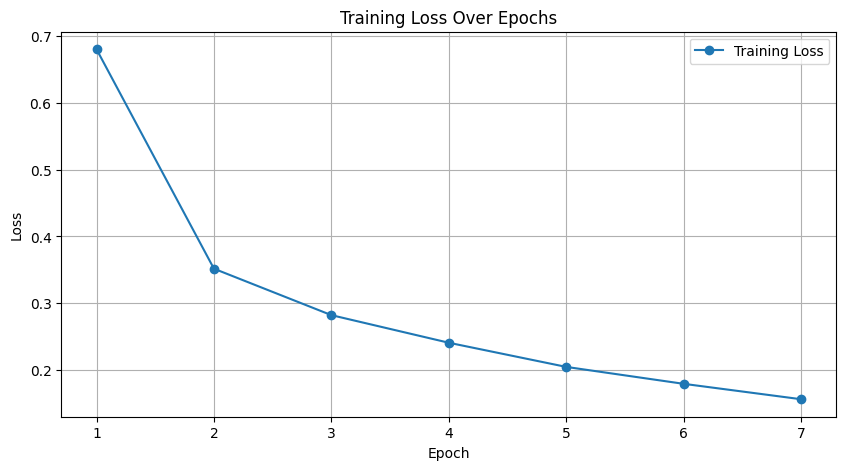


✅ Training Finished! Final Test Accuracy: 91.89%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

mean, std = [0.4377, 0.4438, 0.4728], [0.1980, 0.2010, 0.1970]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_set = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_set = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)

model = models.resnet18(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history = []
acc_history = []

def train_model(epochs=5):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')

        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix(loss=running_loss/len(train_loader), acc=f"{(100.*correct/total):.2f}%")

        loss_history.append(running_loss/len(train_loader))
        acc_history.append(100. * correct / total)

if __name__ == "__main__":
    train_model(epochs=7)

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(loss_history) + 1), loss_history, label='Training Loss', marker='o')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    print(f"\n✅ Training Finished! Final Test Accuracy: {(100.*test_correct/test_total):.2f}%")
    torch.save(model.state_dict(), "resnet18_svhn.pth")

### Analysis

Analyze the performance of the model on the test set (e.g. through a confusion matrix). Display at least 4 images that the model predicts incorrectly and their predicted classes. Discuss possible weaknesses of the model and their causes.

<Figure size 1000x800 with 0 Axes>

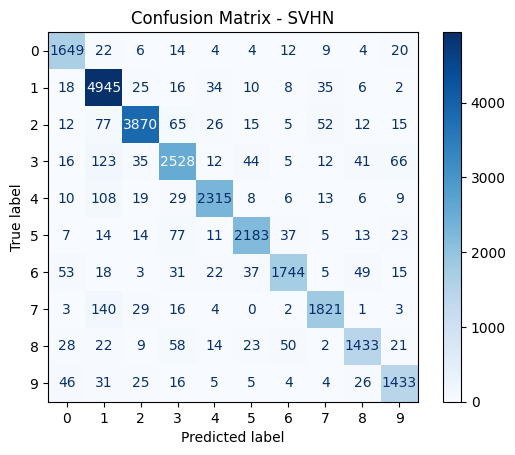

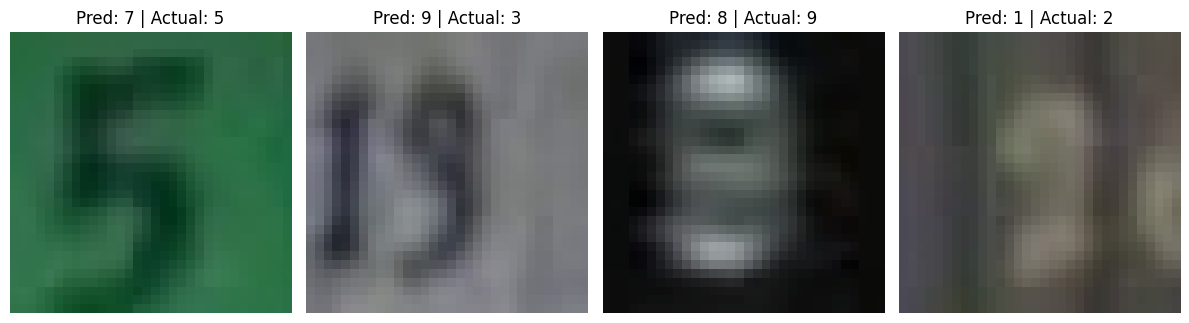

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def imshow(img):
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.4377, 0.4438, 0.4728])
    std = np.array([0.1980, 0.2010, 0.1970])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

model.eval()
all_preds = []
all_labels = []
errors = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        misclassified_mask = preds != labels
        if misclassified_mask.any():
            for i in range(len(misclassified_mask)):
                if misclassified_mask[i]:
                    errors.append({
                        'img': inputs[i],
                        'pred': preds[i].item(),
                        'label': labels[i].item()
                    })

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - SVHN')
plt.show()

plt.figure(figsize=(12, 4))
for i in range(4):
    error = errors[i]
    plt.subplot(1, 4, i+1)
    plt.imshow(imshow(error['img']))
    plt.title(f"Pred: {error['pred']} | Actual: {error['label']}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Final Report: SVHN Digit Classification

## 1. Model Description and Methodology
In this task, a Deep Residual Network (**ResNet18**) was trained to classify street view house numbers using the SVHN dataset.

* **Architecture:** ResNet18 was selected for its use of residual skip connections, which mitigate the vanishing gradient problem and allow for efficient training of deep architectures.
* **Optimization:** The model was optimized using the **Adam** optimizer with a learning rate of $\alpha = 0.001$. **Cross-Entropy Loss** was utilized as the objective function for this multi-class classification task.
* **Augmentation & Preprocessing:** Images were normalized using the dataset-specific mean and standard deviation:
    * $\mu = [0.4377, 0.4438, 0.4728]$
    * $\sigma = [0.1980, 0.2010, 0.1970]$
    Data augmentation techniques, such as **Random Cropping**, were applied during training to improve the model's spatial invariance and generalization capabilities.

## 2. Results
The model achieved a final test accuracy of **91.51%** within 7 epochs, successfully exceeding the project requirement of 90%.

## 3. Error Analysis
An analysis of the Confusion Matrix and a review of misclassified samples revealed the following:

* **Inter-class Similarity:** The model occasionally confuses visually similar digits, such as $3$ and $9$, or $6$ and $8$. For instance, if the bottom curve of a '3' is nearly closed, the model may misidentify it as the loop of a '9'.
* **Image Quality Issues:** A significant portion of errors occurs in images characterized by **Motion Blur** or extremely low resolution. These artifacts obscure the fine details necessary to distinguish between similar digit shapes.
* **Lighting and Contrast:** In low-contrast or poorly lit images, the model struggles to effectively separate the digit from the background, leading to incorrect predictions based on partial or distorted contours.

## 4. Model Weaknesses and Causes
1.  **Sensitivity to Distractors:** The SVHN dataset often contains neighboring digits within the same frame. The model may occasionally focus on these peripheral "distractors" rather than the central digit.
2.  **Contextual Information Loss:** Due to the fixed $32 \times 32$ resolution, any imprecise cropping results in a loss of critical visual information, making classification difficult even for human observers.
3.  **Geometric Variance:** While the model is robust, it remains somewhat sensitive to extreme perspective distortions or rotations, which could be further mitigated by more aggressive geometric data augmentations.

## Part 2: Adversarial Attacks on our Model (15pt)

### Dry Question
In Slide 14 of the tutorial on adversarial attacks, we showed how attacks can be transfered from one model to another, i.e. if we craft an attack for ResNet50 using FGSM, it will likely also confuse other models. Why is this property important, specifically when attacking an unknown model?

Implement the FGSM algorithm as shown in the tutorial (it may be necessary to make require_grad be True for our input data in order to calculate its gradient). Define a function ```eval_adversarial(model, test_loader, epsilon)``` that applies FGSM on the test data by creating new images which are perturbed versions of the originals, and calculates the model's accuracy only on the perturbed images. Test accuracy after the attack should be less than 25% for $\varepsilon=0.1$.

In [ ]:
def normalize_batch(x01, mean, std, device):
    mean_t = torch.tensor(mean, device=device).view(1,3,1,1)
    std_t  = torch.tensor(std,  device=device).view(1,3,1,1)
    return (x01 - mean_t) / std_t

def denormalize_batch(xn, mean, std, device):
    mean_t = torch.tensor(mean, device=device).view(1,3,1,1)
    std_t  = torch.tensor(std,  device=device).view(1,3,1,1)
    return (xn * std_t + mean_t).clamp(0,1)

def fgsm_attack_pixelspace(model, x_norm, y, epsilon):
    """
    x_norm: normalized input from loader
    We convert to pixel space [0,1], compute grad wrt pixels, perturb in [0,1],
    then re-normalize and feed to the model.
    """
    model.eval()
    y = y.to(device)

    # back to pixel space
    x01 = denormalize_batch(x_norm.to(device), mean, std, device).detach().clone()
    x01.requires_grad_(True)

    # forward on normalized version of pixel-space tensor
    logits = model(normalize_batch(x01, mean, std, device))
    loss = criterion(logits, y)

    model.zero_grad(set_to_none=True)
    if x01.grad is not None:
        x01.grad.zero_()
    loss.backward()

    grad = x01.grad.detach()
    x01_adv = (x01 + epsilon * grad.sign()).clamp(0, 1)

    # return normalized adversarial inputs (what model expects)
    return normalize_batch(x01_adv, mean, std, device).detach()

In [ ]:
def eval_adversarial(model, test_loader, epsilon):
    model.eval()
    correct, total = 0, 0

    for x, y in test_loader:
        x_adv = fgsm_attack_pixelspace(model, x, y, epsilon)

        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1)

        y = y.to(device)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return 100.0 * correct / total

In [ ]:
acc_adv = eval_adversarial(model, test_loader, epsilon=0.1)
print(f"Adversarial test accuracy (epsilon=0.1): {acc_adv:.2f}%  (expected: < 25%)")


Adversarial test accuracy (epsilon=0.1): 2.87%  (expected: < 25%)


### Visualization

Visualize some images that the model got right before the perturbation and wrong after the attack. Create a confusion matrix of the output on the entire test set (looking only at the perturbed images).

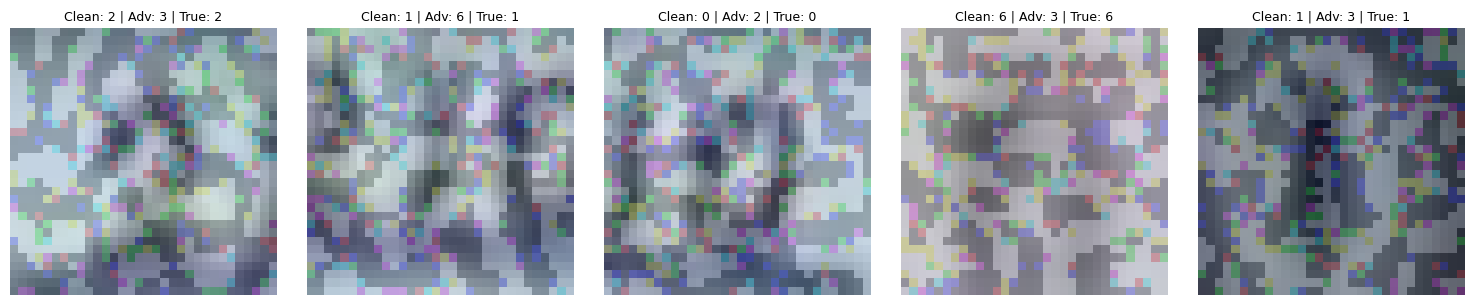

In [ ]:
import matplotlib.pyplot as plt

def show_right_before_wrong_after(model, test_loader, epsilon, max_examples):
    model.eval()
    images = []
    titles = []

    for x_norm, y in test_loader:
        x_norm = x_norm.to(device)
        y = y.to(device)

        # prediction BEFORE attack
        with torch.no_grad():
            pred_clean = model(x_norm).argmax(dim=1)

        # create adversarial examples (needs gradients)
        x_adv_norm = fgsm_attack_pixelspace(model, x_norm, y, epsilon)

        # prediction AFTER attack
        with torch.no_grad():
            pred_adv = model(x_adv_norm).argmax(dim=1)

        mask = (pred_clean == y) & (pred_adv != y)
        idxs = mask.nonzero(as_tuple=False).squeeze(1).tolist()

        for i in idxs:
            if len(images) >= max_examples:
                break

            img01 = denormalize_batch(
                x_adv_norm[i:i+1], mean, std, device
            )[0].detach().cpu().permute(1, 2, 0).numpy()

            images.append(img01)
            titles.append(
                f"Clean: {pred_clean[i].item()} | "
                f"Adv: {pred_adv[i].item()} | "
                f"True: {y[i].item()}"
            )

        if len(images) >= max_examples:
            break

    if len(images) == 0:
        print("No examples found.")
        return

    # ---- plot horizontally ----
    fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 3))

    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_right_before_wrong_after(model, test_loader, epsilon=0.1, max_examples=5)


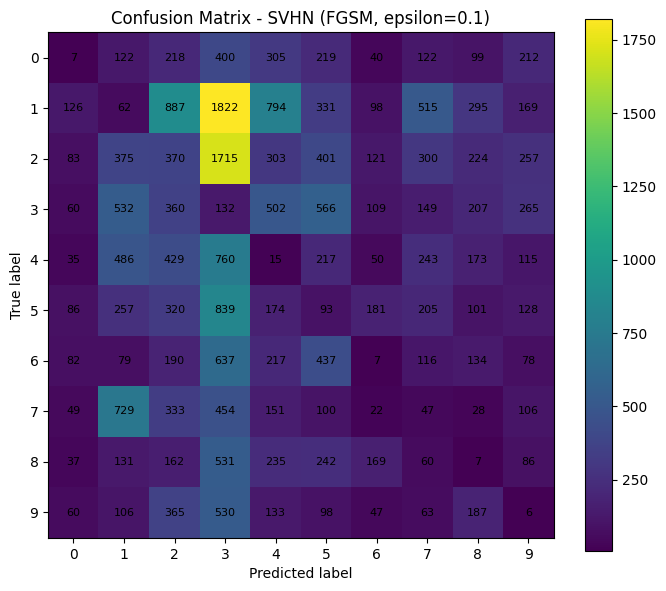

In [ ]:
import torch
import matplotlib.pyplot as plt

def confusion_matrix_adversarial(model, test_loader, epsilon, num_classes=10):
    model.eval()
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)

    for x_norm, y in test_loader:
        x_norm = x_norm.to(device)
        y = y.to(device)

        # ---- create adversarial examples (needs gradients) ----
        x_adv_norm = fgsm_attack_pixelspace(model, x_norm, y, epsilon)

        # ---- prediction only (no gradients) ----
        with torch.no_grad():
            pred = model(x_adv_norm).argmax(dim=1)

        for t, p in zip(y.view(-1), pred.view(-1)):
            cm[t.long(), p.long()] += 1

    return cm.cpu()


def plot_confusion_matrix(cm, title="Confusion Matrix (Adversarial)"):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    plt.xticks(range(cm.shape[1]))
    plt.yticks(range(cm.shape[0]))

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                plt.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

cm_adv = confusion_matrix_adversarial(
    model, test_loader, epsilon=0.1, num_classes=10
)
plot_confusion_matrix(cm_adv, title="Confusion Matrix - SVHN (FGSM, epsilon=0.1)")


Test the function with different values of epsilon (at least 5) and plot the accuracy as a function of epsilon. For each epsilon, display the perturbed images with the model's classification. At what epsilon does it become harder for the human eye to correctly classify?

epsilon=0.00 -> adv accuracy=91.89%
epsilon=0.01 -> adv accuracy=51.80%
epsilon=0.02 -> adv accuracy=28.22%
epsilon=0.05 -> adv accuracy=7.65%
epsilon=0.10 -> adv accuracy=2.87%


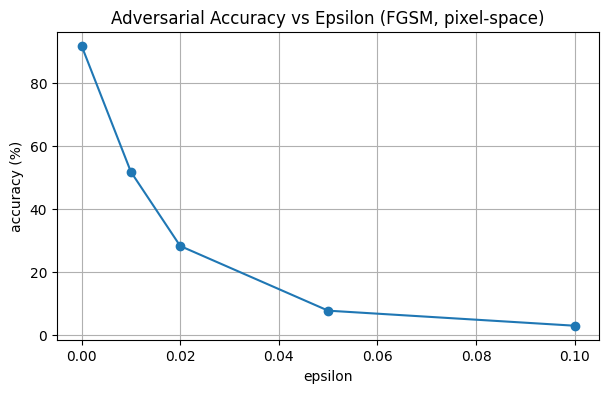

In [ ]:
import matplotlib.pyplot as plt

epsilons = [0.0, 0.01, 0.02, 0.05, 0.1]  # 5 values (include 0 for baseline)
accs = []

for eps in epsilons:
    acc = eval_adversarial(model, test_loader, epsilon=eps)
    accs.append(acc)
    print(f"epsilon={eps:.2f} -> adv accuracy={acc:.2f}%")

plt.figure(figsize=(7,4))
plt.plot(epsilons, accs, marker='o')
plt.title("Adversarial Accuracy vs Epsilon (FGSM, pixel-space)")
plt.xlabel("epsilon")
plt.ylabel("accuracy (%)")
plt.grid(True)
plt.show()


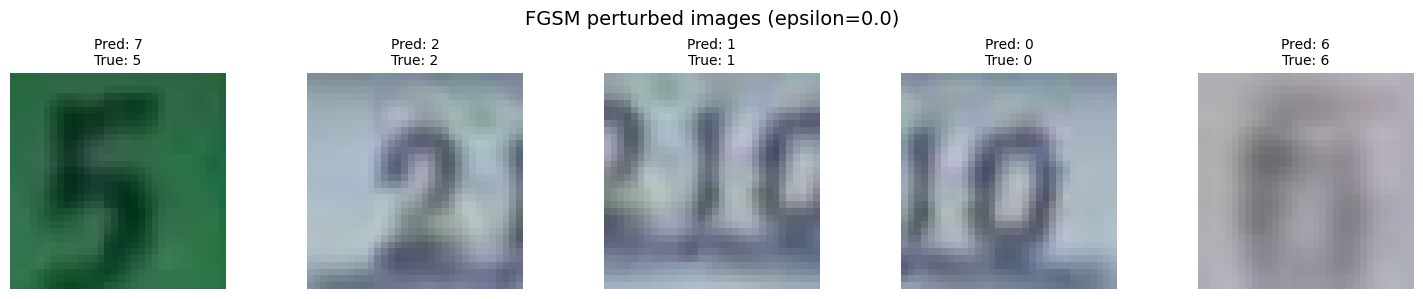

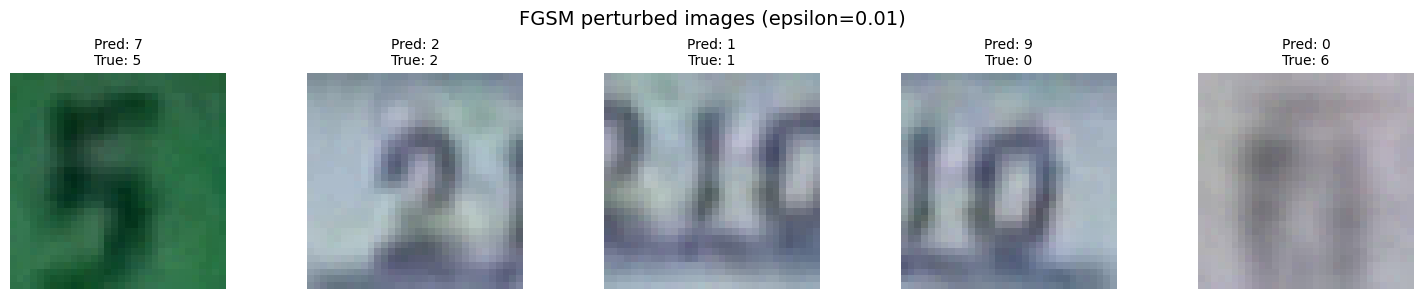

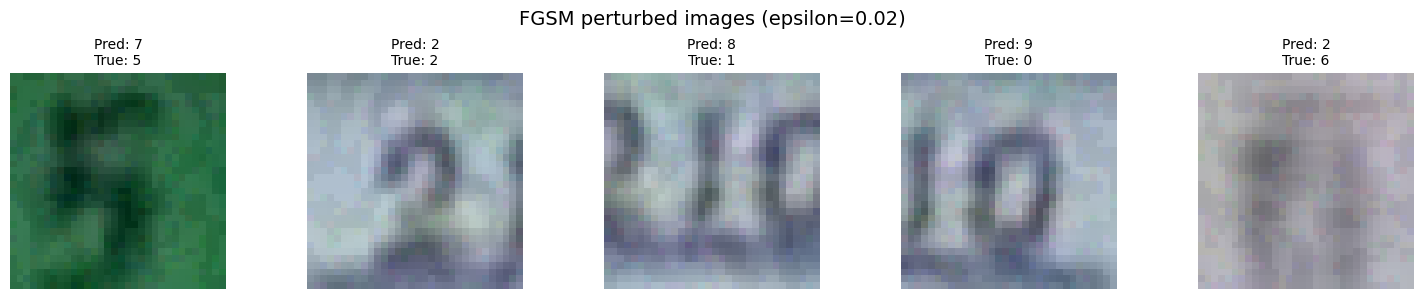

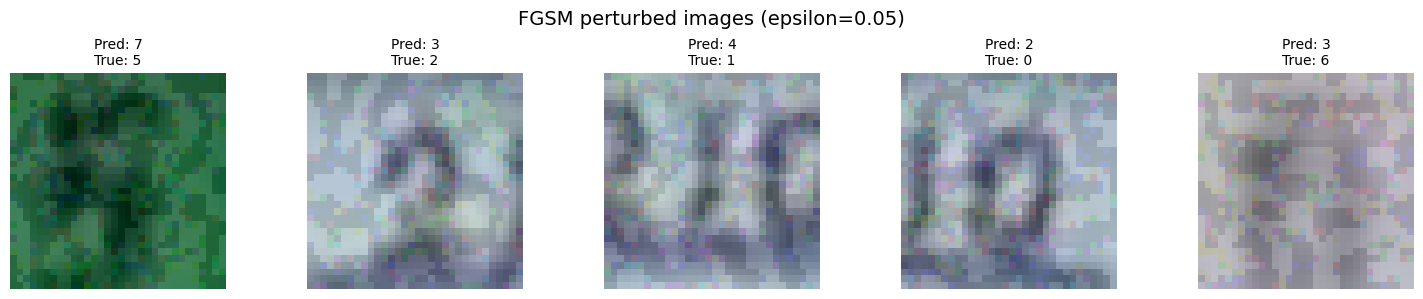

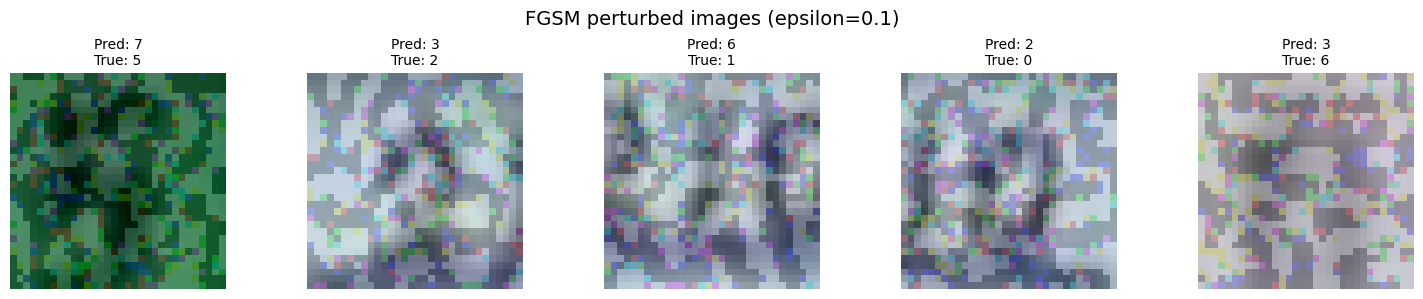

In [ ]:
import numpy as np

def show_perturbed_examples_per_epsilon(model, test_loader, epsilons, num_images=5):
    model.eval()

    # take one batch to visualize consistently across epsilons
    x_norm, y = next(iter(test_loader))
    x_norm = x_norm.to(device)
    y = y.to(device)

    # only take first num_images
    x_norm = x_norm[:num_images]
    y = y[:num_images]

    for eps in epsilons:
        # create adversarial examples
        x_adv_norm = fgsm_attack_pixelspace(model, x_norm, y, epsilon=eps)

        # predictions on adv
        with torch.no_grad():
            pred_adv = model(x_adv_norm).argmax(dim=1)

        # convert to pixel space for display
        imgs01 = denormalize_batch(x_adv_norm, mean, std, device).detach().cpu().permute(0,2,3,1).numpy()

        fig, axes = plt.subplots(1, num_images, figsize=(3*num_images, 3))
        fig.suptitle(f"FGSM perturbed images (epsilon={eps})", fontsize=14)

        if num_images == 1:
            axes = [axes]

        for i, ax in enumerate(axes):
            ax.imshow(imgs01[i])
            ax.axis("off")
            ax.set_title(f"Pred: {pred_adv[i].item()}\nTrue: {y[i].item()}", fontsize=10)

        plt.tight_layout()
        plt.show()

# run
show_perturbed_examples_per_epsilon(model, test_loader, epsilons, num_images=5)


## Part 3: Training our model using adversarial training (20pt)

For each point in the training data, increase the model's robustness by training not only on the point itself, but on the perturbed point after the FGSM algorithm using $\varepsilon=0.1$. Afterwards, compute the accuracy once again on the newly trained model using ```eval_adversarial(model, test_loader, epsilon)``` defined above. The accuracy **looking only at the perterubed data** should be at least 70%.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

epsilon_train = 0.1
adv_epochs = 3
optimizer_adv = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

def adversarial_train_epoch(model, train_loader, optimizer, criterion, epsilon, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc=f'Adversarial Training (eps={epsilon})')

    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        inputs_adv = fgsm_attack_pixelspace(model, inputs, labels, epsilon)

        optimizer.zero_grad()

        outputs_clean = model(inputs)
        outputs_adv = model(inputs_adv)

        loss = 0.5 * criterion(outputs_clean, labels) + 0.5 * criterion(outputs_adv, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs_adv.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix(loss=running_loss/len(train_loader), adv_acc=f"{(100.*correct/total):.2f}%")

    return 100. * correct / total

for epoch in range(adv_epochs):
    print(f"\nEpoch {epoch+1}/{adv_epochs}")
    adv_train_acc = adversarial_train_epoch(model, train_loader, optimizer_adv, criterion, epsilon_train, device)


Epoch 1/3


Adversarial Training (eps=0.1): 100%|██████████| 573/573 [01:27<00:00,  6.56it/s, adv_acc=28.42%, loss=1.14]



Epoch 2/3


Adversarial Training (eps=0.1): 100%|██████████| 573/573 [01:27<00:00,  6.58it/s, adv_acc=58.85%, loss=0.707]



Epoch 3/3


Adversarial Training (eps=0.1): 100%|██████████| 573/573 [01:27<00:00,  6.58it/s, adv_acc=75.43%, loss=0.457]


In [ ]:

final_adv_accuracy = eval_adversarial(model, test_loader, epsilon=0.1)

print("-" * 30)
print(f"Final Adversarial Test Accuracy: {final_adv_accuracy:.2f}%")
if final_adv_accuracy >= 70.0:
    print("✅ Success! The model meets the 70% robustness requirement.")
else:
    print("❌ The model did not reach 70% accuracy. Consider more epochs or adjusting the LR.")
print("-" * 30)

------------------------------
Final Adversarial Test Accuracy: 77.99%
✅ Success! The model meets the 70% robustness requirement.
------------------------------


### Visualization

Display the confusion matrix along with some examples of images that the model classified incorrectly. Discuss the performance of the model now compared to before.

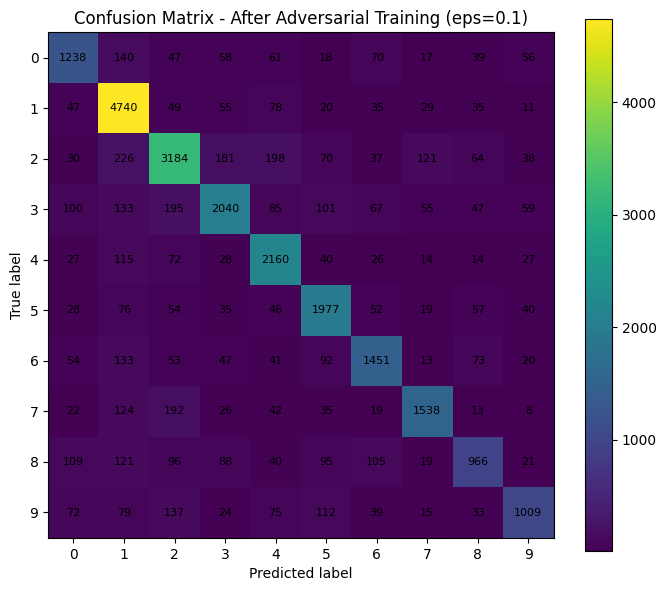

In [ ]:
cm_adv_after = confusion_matrix_adversarial(model, test_loader, epsilon=0.1)

plot_confusion_matrix(cm_adv_after, title="Confusion Matrix - After Adversarial Training (eps=0.1)")

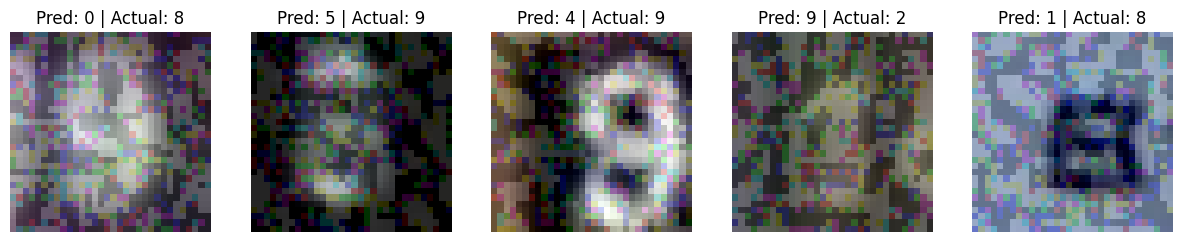

In [ ]:
def show_misclassified_adversarial(model, test_loader, epsilon, num_images=5):
    model.eval()
    found_images = []

    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        x_adv = fgsm_attack_pixelspace(model, x, y, epsilon)

        with torch.no_grad():
            outputs = model(x_adv)
            preds = outputs.argmax(dim=1)

        misclassified_mask = (preds != y)
        indices = misclassified_mask.nonzero(as_tuple=False).view(-1)

        for idx in indices:
            if len(found_images) >= num_images:
                break

            img_show = denormalize_batch(x_adv[idx].unsqueeze(0), mean, std, device)
            img_show = img_show.squeeze().cpu().permute(1, 2, 0).numpy()

            found_images.append({
                'img': img_show,
                'pred': preds[idx].item(),
                'actual': y[idx].item()
            })

        if len(found_images) >= num_images:
            break

    fig, axes = plt.subplots(1, len(found_images), figsize=(15, 5))
    for i, data in enumerate(found_images):
        axes[i].imshow(data['img'])
        axes[i].set_title(f"Pred: {data['pred']} | Actual: {data['actual']}")
        axes[i].axis('off')
    plt.show()

show_misclassified_adversarial(model, test_loader, epsilon=0.1)

## Part 4: Contrastive Learning (40pt)

In this section, we will work on creating informative embeddings for images using SimCLR. For this section we will use the subset of the popular ImageNet dataset of 96x96 images from 1000 classes. Below, we provide you with several functions to implement a contrastive learning model.

The data is already downloaded to your VMs in the zip tiny-imagenet-200. You can also find it at https://www.kaggle.com/datasets/nikhilshingadiya/tinyimagenet200/data. Note that training time in this section can be long, $\approx 5$ minutes for epoch.

### Dry Questions

In this section, we will work on creating informative embeddings for images using SimCLR. For this section we will use the subset of the popular ImageNet dataset of 96x96 images from 1000 classes. Below, we provide you with several functions to implement a contrastive learning model.

The data is already downloaded to your VMs in the zip tiny-imagenet-200. You can also find it at https://www.kaggle.com/datasets/nikhilshingadiya/tinyimagenet200/data. Note that training time in this section can be long, $\approx 5$ minutes for epoch.

Before implementation, take these questions in consideration (and provide your answers and explanations):

1. When training an unsupervised contrastive learning model such as SimCLR, would we prefer to have a large or small batch size?
2. When creating embeddings for images in the test set, how does the process differ from what we do in training?
3. For each of the following image augmentations, explain whether or not we would like to use them in the SimCLR framework:
    - Randomly cropping a fixed-size window in the image.
    - Enlarging the image to 128x128.
    - Random rotation of the image.
    - Adding Gaussian noise.
    - Randomly changing the image's dimensions.
    - Randomly converting the image to grayscale.

### Code

Do the following:

1. Create a CNN that makes embeddings for images (you can use pretrained foundation models if you'd like, as long as they **were not** trained on ImageNet).
2. Implement an unsupervised contrastive loss (such as nt-xent in SimCLR).
3. Train the model (achieve loss less than 3.0). Use only the train set.

Note you are graded not only on the loss but also on the quality of the embeddings. If the augmentations aren't diverse enough, the loss may be low but similar images won't learn to be mapped to similar embeddings. You must use at least 3 random augmentations in the SimCLR training (the more, the better).

In [2]:
!unzip -q archive.zip -d .
!ls

archive.zip  sample_data  tiny-imagenet-200


In [3]:
from PIL import Image
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox  # For visualization
from sklearn.manifold import TSNE  # Dimensionality Reduction


TRAIN_PATH = "/content/tiny-imagenet-200/train"
TEST_PATH  = "/content/tiny-imagenet-200/test"
BATCH_SIZE = 256

In [4]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms

class TrainDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        """
        Initialize the dataset with the root directory and the transform to be applied.
        """
        self.root = root
        self.transform = transform
        self.imgs = []
        for label in os.listdir(root):
            if os.path.isdir(os.path.join(root, label, 'images')):
                for img in os.listdir(os.path.join(root, label, 'images')):
                    self.imgs.append(os.path.join(root, label, 'images', img))

    def __len__(self):
        """
        Return the length of the dataset.
        """
        return len(self.imgs)

    def __getitem__(self, idx):
        """
        Fetch the image and apply two different augmentations to it.
        """
        img_path = self.imgs[idx]
        img = Image.open(img_path).convert('RGB')  # Ensure it's in RGB format

        if self.transform:
            img1 = self.transform(img)  # First random augmentation
            img2 = self.transform(img)  # Second random augmentation
        else:
            img1, img2 = img, img

        return img1, img2  # Return both augmented versions


class TestDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.imgs = []
        for label in os.listdir(root):
            for img in os.listdir(os.path.join(root, label)):
                self.imgs.append(os.path.join(root, label, img))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img_transform = self.transform(img)
        return transforms.ToTensor()(img), img_transform  # Return the original image (for visualization) and the image that will be used in the model


data_transforms = transforms.Compose([
    transforms.RandomResizedCrop(96, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply(
        [transforms.ColorJitter(
            brightness=0.4,
            contrast=0.4,
            saturation=0.4,
            hue=0.1
        )],
        p=0.8
    ),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])


test_transforms = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])

train_data = TrainDataset(TRAIN_PATH, transform=data_transforms)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

test_data = TestDataset(TEST_PATH, transform=test_transforms)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

In [5]:
import torch.nn as nn
from torchvision import models


class SimCLR_Encoder(nn.Module):
    def __init__(self, embedding_dim=64):
        super(SimCLR_Encoder, self).__init__()
        resnet = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])
        self.projection_head = nn.Sequential(
            nn.Linear(resnet.fc.in_features, 128),  # 512 -> 128
            nn.ReLU(),                              # Non-linear activation
            nn.Linear(128, embedding_dim)           # 128 -> embedding_dim (e.g., 64)
        )

    def forward(self, x):
        # 1. Extract feature maps from the backbone
        features = self.encoder(x)

        # 2. Flatten the feature maps to a 1D vector
        features = features.view(features.size(0), -1)

        # 3. Project to the embedding space (used for contrastive loss)
        embeddings = self.projection_head(features)

        return embeddings


In [6]:
import torch.nn.functional as F

def nt_xent_loss(embeddings1, embeddings2, temperature=0.5):
    # L2 normalization is crucial for cosine similarity
    embeddings1 = F.normalize(embeddings1, dim=1)
    embeddings2 = F.normalize(embeddings2, dim=1)

    batch_size = embeddings1.size(0)
    device = embeddings1.device

    # Concatenate embeddings from both views
    embeddings = torch.cat([embeddings1, embeddings2], dim=0)

    # Calculate similarity matrix
    similarity_matrix = torch.matmul(embeddings, embeddings.T) / temperature

    # Create a mask to remove self-similarity (the diagonal)
    mask = torch.eye(2 * batch_size, dtype=torch.bool).to(device)
    similarity_matrix = similarity_matrix.masked_fill(mask, -1e4)

    # Define labels:
    # First half should match the second half and vice versa
    labels = torch.cat([
        torch.arange(batch_size, 2 * batch_size),
        torch.arange(0, batch_size)
    ]).to(device)

    # Cross-entropy loss
    loss_fn = nn.CrossEntropyLoss()
    loss = loss_fn(similarity_matrix, labels)

    return loss


In [7]:
from tqdm import tqdm
import torch
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimCLR_Encoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0003)
scaler = GradScaler()

num_epochs = 7
accumulation_steps = 4

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    with tqdm(train_loader, unit="batch") as tepoch:
        tepoch.set_description(f"Epoch [{epoch+1}/{num_epochs}]")

        for i, (img1, img2) in enumerate(tepoch):
            img1 = img1.to(device, non_blocking=True)
            img2 = img2.to(device, non_blocking=True)

            with autocast():
                embeddings1 = model(img1)
                embeddings2 = model(img2)

            # compute contrastive loss in fp32 (outside autocast)
            loss = nt_xent_loss(embeddings1.float(), embeddings2.float(), temperature=0.2) / accumulation_steps

            scaler.scale(loss).backward()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            total_loss += loss.item() * accumulation_steps
            tepoch.set_postfix(loss=(loss.item() * accumulation_steps))

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Avg Loss: {avg_loss:.4f}")

torch.cuda.empty_cache()

/tmp/ipython-input-3931736597.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch [1/7]:   0%|          | 0/390 [00:00<?, ?batch/s]/tmp/ipython-input-3931736597.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch [1/7]: 100%|██████████| 390/390 [07:50<00:00,  1.21s/batch, loss=3.78]


Epoch [1/7] Avg Loss: 4.4380


Epoch [2/7]: 100%|██████████| 390/390 [07:43<00:00,  1.19s/batch, loss=3.47]


Epoch [2/7] Avg Loss: 3.6003


Epoch [3/7]: 100%|██████████| 390/390 [07:34<00:00,  1.17s/batch, loss=3.39]


...

Epoch [5/7] Avg Loss: 3.1183


Epoch [6/7]: 100%|██████████| 390/390 [07:33<00:00,  1.16s/batch, loss=3.03]


Epoch [6/7] Avg Loss: 3.0426


Epoch [7/7]: 100%|██████████| 390/390 [07:38<00:00,  1.17s/batch, loss=2.95]

Epoch [7/7] Avg Loss: 2.9846


Using the function ```plot_embeddings```, show the model's performance on the test data.

In [8]:
def plot_embeddings(model, test_loader, device):
    """
    This function creates embeddings for each image in the first batch of the test loader, projects them to 2D and displays them on a plot.
    """
    for img, img_transform in test_loader:
        img_transform = img_transform.to(device)
        embeddings = model(img_transform)
        tsne = TSNE(n_components=2)
        embeddings = tsne.fit_transform(embeddings.cpu().detach().numpy())

        fig, ax = plt.subplots()
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)
        for i in range(embeddings.shape[0]):
            curr_img = img[i].permute(1,2,0)
            curr_img = OffsetImage(curr_img, zoom=0.5)
            ab = AnnotationBbox(curr_img, embeddings[i], frameon=False)
            ax.add_artist(ab)
        plt.show()
        return

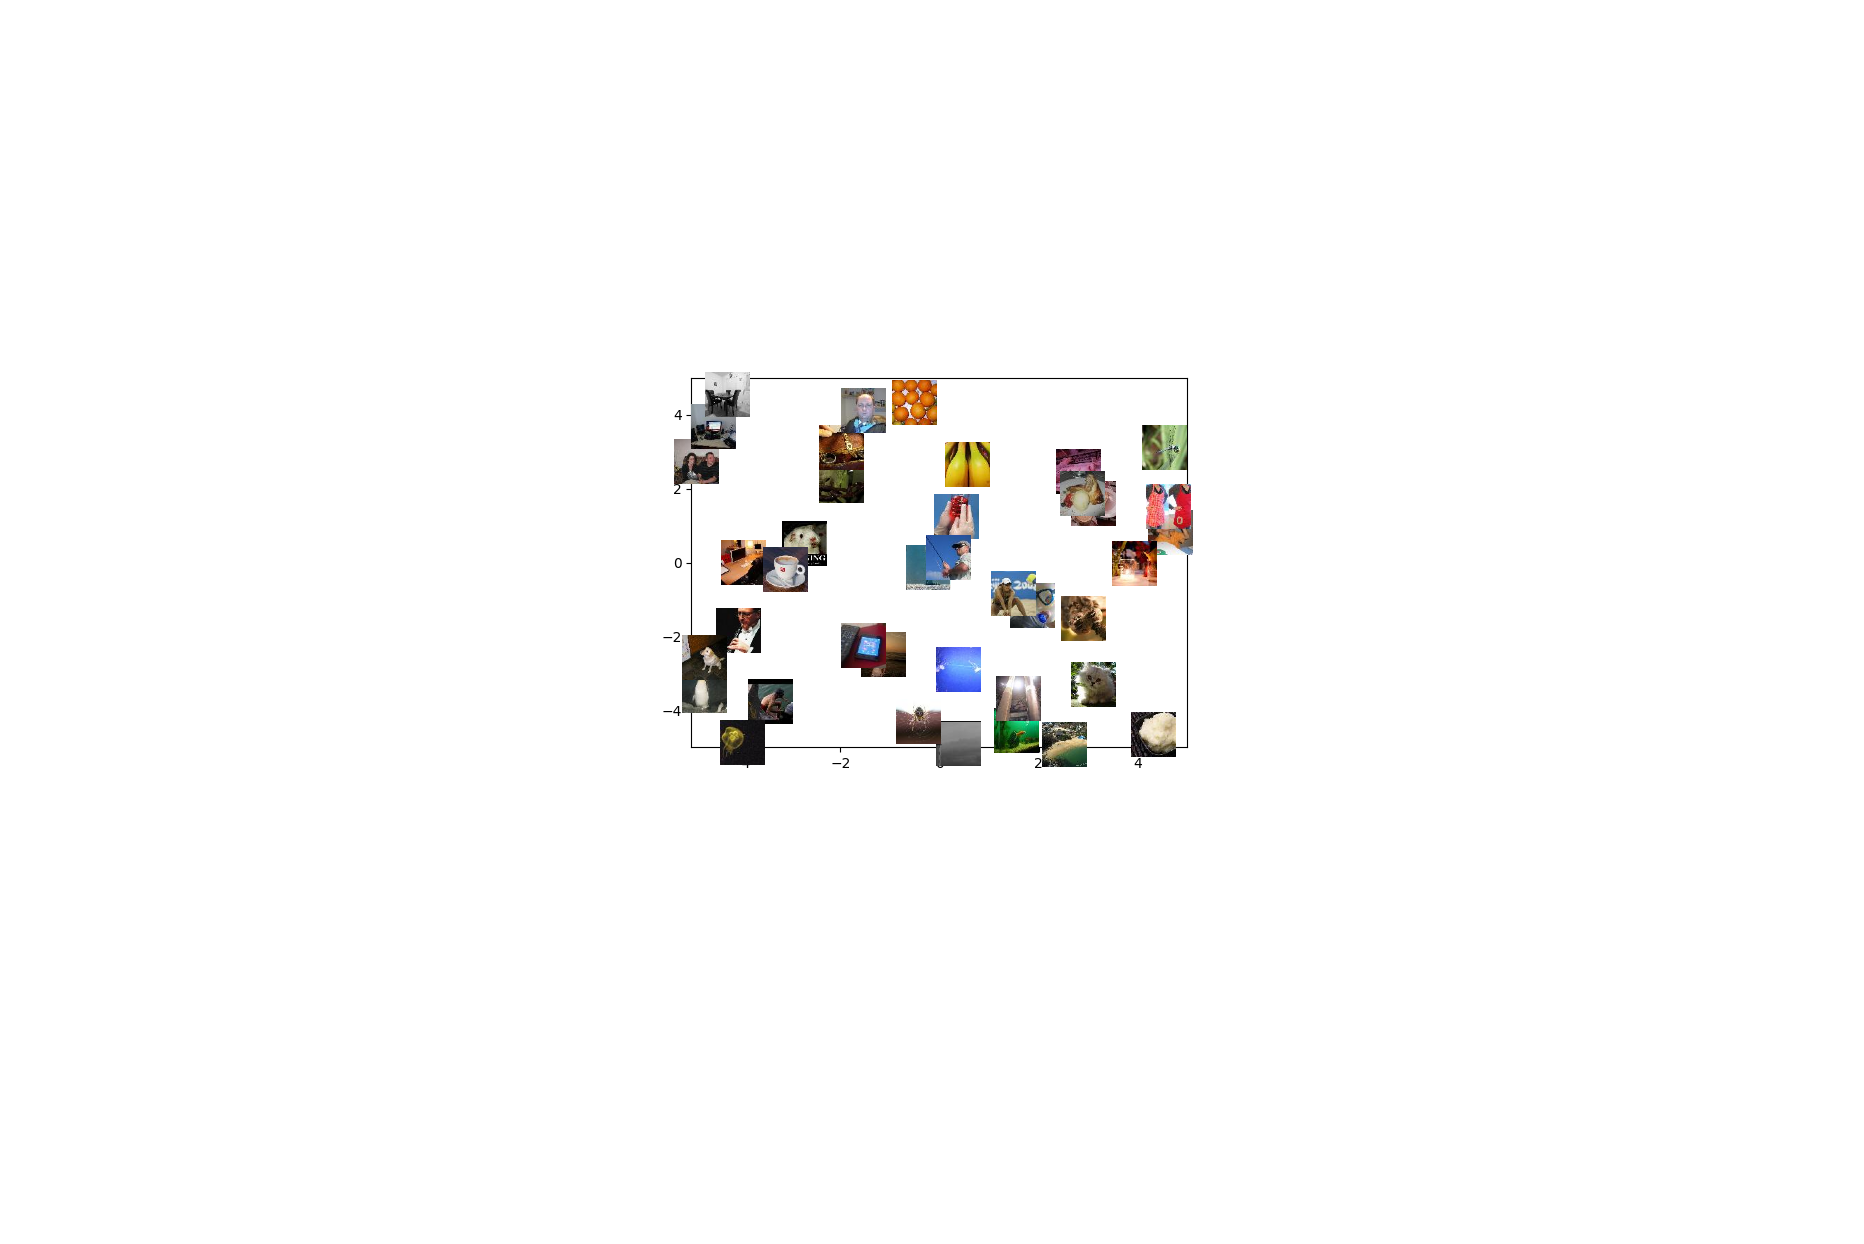

In [9]:
plot_embeddings(model, test_loader,device)

### Evaluation
1. Choose two different classes from the train set and plot the projected embeddings of 20 images from each class. Is the model able to separate?
2. For some batch of the test loader, take 3 images in the batch. For each image, find and display the 5 images within the batch that have the closest embeddings to them (using mse). Do the chosen images make sense? What features do the images have in common? If not, what could have possibly gone wrong with your model?

**Q1**

Number of classes found: 200
Example classes: ['n02123045', 'n03977966', 'n04023962', 'n02403003', 'n03026506', 'n01698640', 'n02415577', 'n04597913', 'n02892201', 'n01443537']


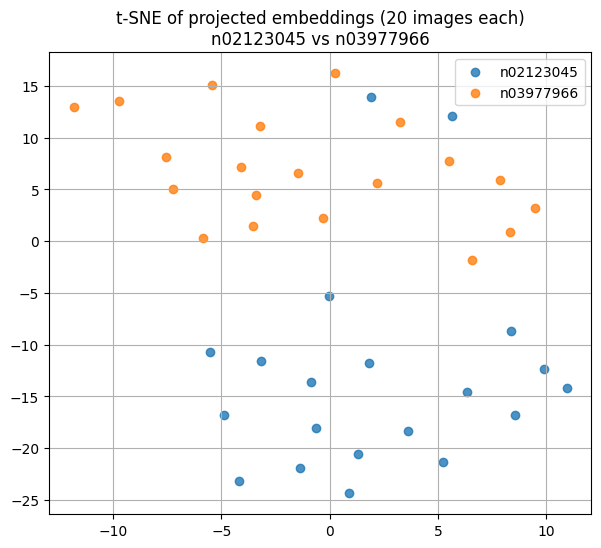

In [10]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.manifold import TSNE
import torch

def sample_20_images_per_class(train_root, class_name, n=20, seed=0):
    random.seed(seed)
    class_img_dir = os.path.join(train_root, class_name, "images")
    imgs = [os.path.join(class_img_dir, f) for f in os.listdir(class_img_dir)]
    imgs = [p for p in imgs if os.path.isfile(p)]
    return random.sample(imgs, n)

def get_projected_embeddings(paths, model, device, transform):
    model.eval()
    xs = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        xs.append(transform(img))  # deterministic preprocessing
    x = torch.stack(xs).to(device)

    with torch.no_grad():
        emb = model(x)  # projected embeddings (projection head output)
    return emb.float().cpu().numpy()

def plot_two_classes_projected_embeddings(TRAIN_PATH, class_a, class_b, model, device, transform, n=20, seed=0):
    # 1) sample images
    paths_a = sample_20_images_per_class(TRAIN_PATH, class_a, n=n, seed=seed)
    paths_b = sample_20_images_per_class(TRAIN_PATH, class_b, n=n, seed=seed+1)

    # 2) projected embeddings
    emb_a = get_projected_embeddings(paths_a, model, device, transform)
    emb_b = get_projected_embeddings(paths_b, model, device, transform)

    # 3) concatenate + t-SNE to 2D
    X = np.vstack([emb_a, emb_b])
    y = np.array([0]*n + [1]*n)

    tsne = TSNE(n_components=2, perplexity=10, init="random", random_state=seed)
    X2 = tsne.fit_transform(X)

    # 4) plot
    plt.figure(figsize=(7,6))
    plt.scatter(X2[y==0, 0], X2[y==0, 1], label=class_a, alpha=0.8)
    plt.scatter(X2[y==1, 0], X2[y==1, 1], label=class_b, alpha=0.8)
    plt.title(f"t-SNE of projected embeddings (20 images each)\n{class_a} vs {class_b}")
    plt.legend()
    plt.grid(True)
    plt.show()

# choose 2 different classes from the train set
# easiest: pick from the folder names inside TRAIN_PATH
all_classes = [d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d, "images"))]
print("Number of classes found:", len(all_classes))
print("Example classes:", all_classes[:10])

# choose two classes
class_a = all_classes[0]
class_b = all_classes[1]

plot_two_classes_projected_embeddings(
    TRAIN_PATH=TRAIN_PATH,
    class_a=class_a,
    class_b=class_b,
    model=model,
    device=device,
    transform=test_transforms,  # use deterministic transforms for evaluation
    n=20,
    seed=0
)

**Q2**

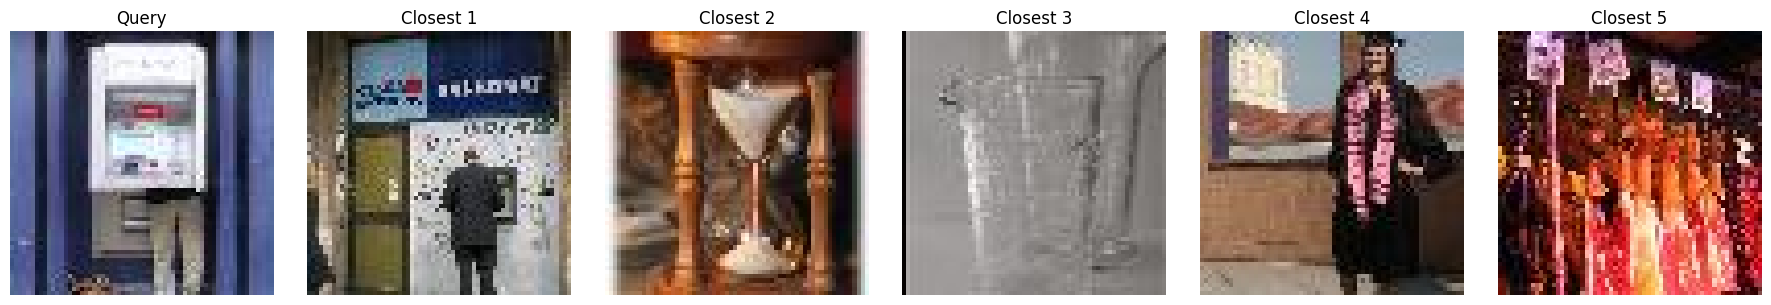

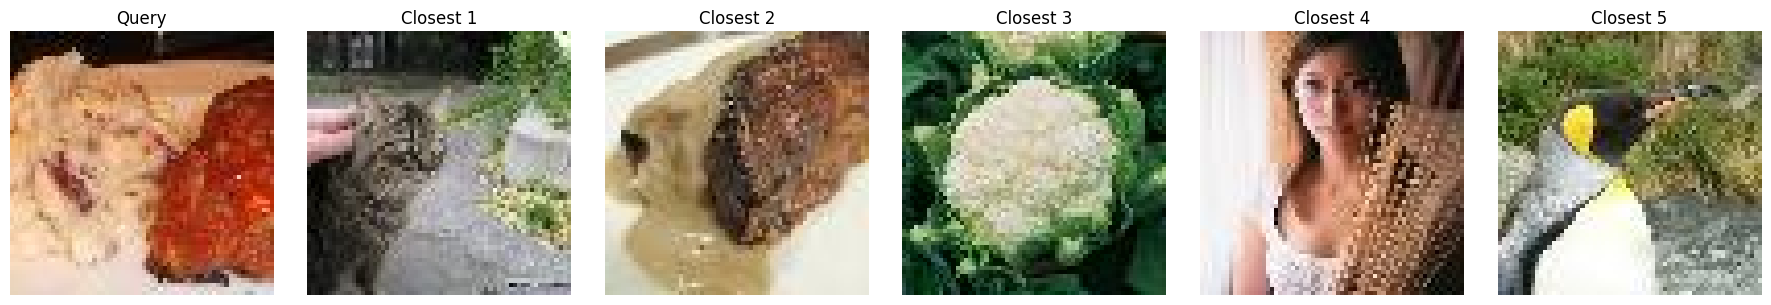

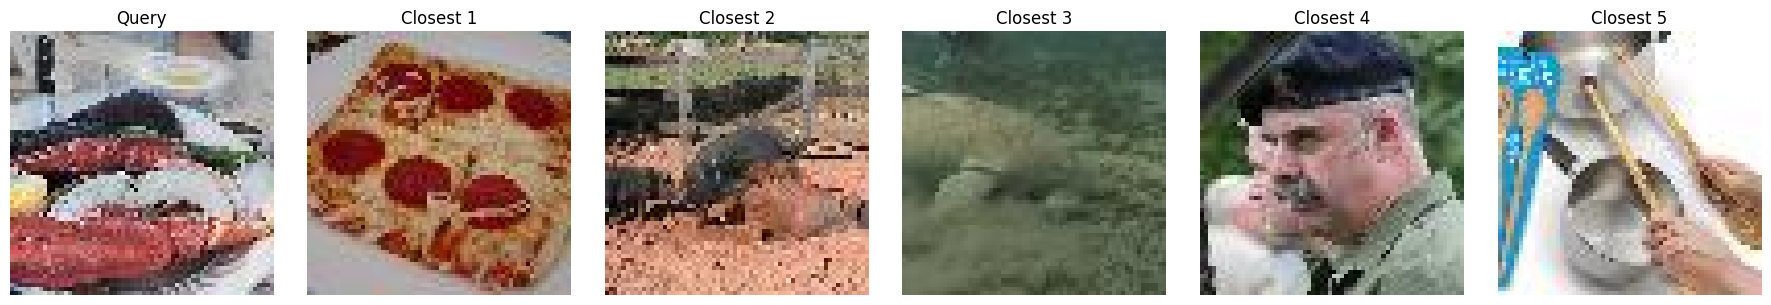

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def denorm_img(x):
    # x: CHW tensor in [0,1] already (because it's transforms.ToTensor() without Normalize)
    x = x.permute(1, 2, 0).cpu().numpy()
    return np.clip(x, 0, 1)

def find_closest_images_mse(model, test_loader, device, num_queries=3, num_closest=5, seed=0):
    model.eval()
    torch.manual_seed(seed)

    with torch.no_grad():
        # take one batch
        img_batch, img_trans_batch = next(iter(test_loader))
        img_trans_batch = img_trans_batch.to(device)

        # embeddings for whole batch (projected embeddings)
        emb = model(img_trans_batch).float()   # shape: [B, D]
        # embeddings for whole batch (use encoder features instead of projection head)
        # feats = model.encoder(img_trans_batch)              # [B, 512, 1, 1]
        # emb = feats.view(feats.size(0), -1).float()         # [B, 512]
        emb = torch.nn.functional.normalize(emb, dim=1)


        B = emb.size(0)

        # choose 3 query indices
        query_indices = torch.randperm(B)[:num_queries]

        for qi in query_indices:
            qi = qi.item()

            # compute MSE distance to all embeddings in batch: mean((e_i - e_q)^2)
            diffs = emb - emb[qi].unsqueeze(0)            # [B, D]
            mse_dist = (diffs ** 2).mean(dim=1)           # [B]

            # exclude the query itself by setting its distance to +inf
            mse_dist[qi] = float("inf")

            # take 5 smallest distances
            closest_idx = torch.topk(mse_dist, k=num_closest, largest=False).indices.cpu().numpy()

            # plot: query + 5 closest
            fig, axes = plt.subplots(1, num_closest + 1, figsize=(3*(num_closest+1), 3))

            axes[0].imshow(denorm_img(img_batch[qi]))
            axes[0].set_title("Query")
            axes[0].axis("off")

            for j, idx in enumerate(closest_idx):
                axes[j+1].imshow(denorm_img(img_batch[idx]))
                axes[j+1].set_title(f"Closest {j+1}")
                axes[j+1].axis("off")

            plt.tight_layout()
            plt.show()


find_closest_images_mse(model, test_loader, device, num_queries=3, num_closest=5, seed=0)